<a href="https://colab.research.google.com/github/abdulhadi2005ag-cmd/flyrank-ml-internship-hadii/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/abdulhadi2005ag-cmd/flyrank-ml-internship-hadii/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Research question:** Among a client's existing content pages, which ones are worth an
editor's limited review time first — and why?

**Decision this supports:** a content/SEO team lead running a weekly or biweekly refresh triage
needs a priority-ordered reading list, not a per-page yes/no. This is Lane 2 —
Refresh / Content Opportunity Scoring — and the deliverable is a ranked action queue with a
stated, auditable reason for every row, not a single accuracy number.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/abdulhadi2005ag-cmd/flyrank-ml-internship-hadii"
REPO_DIR = "flyrank-ml-internship-hadii"
if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

import json
import pandas as pd
import numpy as np
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score

RANDOM_SEED = 1

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print("Loaded:", df.shape)
print("Clients:", df["client_id"].nunique(), "| Content items:", df["content_id"].nunique())

Loaded: (30000, 44)
Clients: 32 | Content items: 30000


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release used:** the anonymized 30,000-row starter sample (`data/raw/content_refresh_anonymized.csv`,
44 columns), the same sample used consistently across w03–w07 so every result here is directly
comparable. w03 additionally cross-checked grain and availability against the full ~79M-row
warehouse (`FlyRank/internship-warehouse` on Hugging Face) via DuckDB — not repeated here to keep
this notebook self-contained and runnable without a gated token.

**Unit of analysis:** one row = one content item (`content_id`) for one client (`client_id`),
with a 90-day trailing performance window per row.

**Label (proxy, never a feature):** `is_declining = 1` if `trend_direction == "down"` — a measured
comparison of a page's own recent window to its own earlier window, not ground truth about search
performance and not a causal claim about Google's algorithm.

**Excluded, and why (public-safe, per `DATA_USE.md`):** no client names/domains/URLs (pre-anonymized);
`impressions_last_30d`/`impressions_prev_30d` and their clicks/sessions siblings (confirmed in w03
to reconstruct the label almost exactly — a sibling-window leak); AI-referral columns (too sparse
at this sample size); pseudonymous IDs (grouping/joining only, never a feature).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
label = (df["trend_direction"] == "down").astype(int)
print("Label base rate (declining share):", round(label.mean(), 3))
print("Rows with no position data (avg_position == 0):", (df["avg_position"] == 0).sum())

Label base rate (declining share): 0.542
Rows with no position data (avg_position == 0): 1205


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Feature set:** 38 columns after one-hot encoding `content_type` / `main_intent` /
`competition_level` and adding `has_*_data` missingness flags.

**Baseline (rule-based, w04):** flag if 90+ days since last update, ≥500 impressions/90d, and
CTR below its own position-tier's median CTR.

**Model:** Random Forest, chosen over Logistic Regression after comparing both on the same
grouped split (computed below).

**Validation design — why grouped, not random:** `client_id` is a grouping key, never a feature —
pages from the same client share a CMS, editorial voice, and traffic baseline. A random row-level
split lets the model partly memorize "how this client's pages behave" instead of generalizing to a
client it hasn't scored before. All splits below use `GroupShuffleSplit` or `GroupKFold`, verified
to have zero client overlap.

**Leakage checks:** re-run below on the final feature set — confirms no label-family columns, no
known-leaky sibling windows, and no ID columns made it into X.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Build the honest, leakage-checked feature set (same as w03/w05/w06/w07):
# candidate columns minus label family, minus the two sibling-window leaks
# (impressions_last_30d/prev_30d + their clicks/sessions siblings), minus IDs.
work = df.copy()
work["has_search_volume_data"] = work["search_volume"].notna().astype(int)
work["has_word_count_data"] = work["word_count"].notna().astype(int)
work["has_position_data"] = (work["avg_position"] > 0).astype(int)

numeric_candidates = [
    "content_age_days", "days_since_last_update", "word_count", "char_count",
    "search_volume", "competition", "cpc",
    "impressions_90d", "clicks_90d", "pageviews_90d", "sessions_90d", "users_90d",
    "engaged_sessions_90d", "ai_sessions_90d", "scroll_events_90d",
    "days_with_impressions", "days_with_sessions",
    "ctr", "avg_position", "engagement_rate", "scroll_rate", "ai_traffic_pct",
]
X_numeric = work[numeric_candidates].fillna(0)
X_numeric = pd.concat(
    [X_numeric, work[["has_search_volume_data", "has_word_count_data", "has_position_data"]]],
    axis=1,
)
categorical_candidates = ["content_type", "main_intent", "competition_level"]
X_categorical = pd.get_dummies(work[categorical_candidates], dummy_na=True, prefix=categorical_candidates)

X = pd.concat([X_numeric, X_categorical], axis=1)
groups = work["client_id"]
print("Feature matrix shape:", X.shape)

# Leakage attack checklist, re-run here on the final set (same checks as w06):
label_family = {"trend_direction", "trend_pct"}
known_leaky = {"impressions_last_30d", "impressions_prev_30d",
               "clicks_last_30d", "clicks_prev_30d", "sessions_last_30d", "sessions_prev_30d"}
id_cols = {"content_id", "client_id"}
print("Label-family columns in X:", sorted(label_family & set(X.columns)) or "none")
print("Known-leaky sibling windows in X:", sorted(known_leaky & set(X.columns)) or "none")
print("ID columns in X:", sorted(id_cols & set(X.columns)) or "none")

Feature matrix shape: (30000, 38)
Label-family columns in X: none
Known-leaky sibling windows in X: none
ID columns in X: none


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

**Computed below, live, on this run:** baseline rule vs. Logistic Regression vs. Random Forest,
all on the same client-grouped holdout — plus the naive-vs-grouped split comparison and the
5-fold stability check. These are the same three findings reported in w05/w06/w07, reproduced
here end-to-end rather than restated.

**What to expect:** Random Forest should show a higher AUC than Logistic Regression and similar
precision@50. The naive random split should show a noticeably higher (inflated) precision@50 than
the grouped split — that gap is the single most important validation finding in this project: a
metric that looks fine (AUC) can hide a split-design problem that a more deployment-relevant
metric (precision@50) catches clearly. The 5-fold spread shows how much that number can move
given only 32 clients — exact figures will vary slightly run-to-run with library versions, but
the direction and shape of each finding should hold.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
def precision_at_k(scores, y_true, k):
    order = np.argsort(-scores)[:k]
    return y_true.iloc[order].mean()

# --- Grouped split (honest, client-level holdout) ---
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X, label, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = label.iloc[train_idx], label.iloc[test_idx]
y_test_r = y_test.reset_index(drop=True)
overlap_grp = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print("Grouped split -- client overlap (must be 0):", len(overlap_grp))

# --- Baseline rule, scored on the test split (same logic as w04) ---
test_df = df.iloc[test_idx].reset_index(drop=True).copy()
clean = df[df["avg_position"] > 0]
tier_median_ctr = clean.groupby("position_tier", observed=True)["ctr"].median()
test_df["has_position_data"] = test_df["avg_position"] > 0
test_df["tier_median_ctr"] = test_df["position_tier"].map(tier_median_ctr)
test_df["stale"] = test_df["days_since_last_update"] >= 90
test_df["has_demand"] = test_df["impressions_90d"] >= 500
test_df["weak_ctr"] = test_df["has_position_data"] & (test_df["ctr"] < test_df["tier_median_ctr"])
flagged = test_df["stale"] & test_df["has_demand"] & test_df["weak_ctr"]
test_df["baseline_score"] = np.where(flagged, test_df["impressions_90d"], 0)
n_flagged = int(flagged.sum())
p50_baseline = precision_at_k(test_df["baseline_score"].values, y_test_r, 50)

# --- Logistic Regression ---
scaler = StandardScaler()
lr = LogisticRegression(max_iter=2000, random_state=RANDOM_SEED)
lr.fit(scaler.fit_transform(X_train), y_train)
lr_proba = lr.predict_proba(scaler.transform(X_test))[:, 1]
lr_auc = roc_auc_score(y_test, lr_proba)
p50_lr = precision_at_k(lr_proba, y_test_r, 50)

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                             random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_proba = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_proba)
p50_rf = precision_at_k(rf_proba, y_test_r, 50)

print(f"\nBaseline flagged {n_flagged} of {len(test_df)} test rows")
print(f"{'Method':<20}{'precision@50':>14}{'AUC':>8}")
print(f"{'Base rate':<20}{y_test.mean():>14.3f}{'-':>8}")
print(f"{'Baseline rule':<20}{p50_baseline:>14.3f}{'-':>8}")
print(f"{'Logistic Regr.':<20}{p50_lr:>14.3f}{lr_auc:>8.3f}")
print(f"{'Random Forest':<20}{p50_rf:>14.3f}{rf_auc:>8.3f}")

# --- Naive random split, same model, for comparison (the w06 finding) ---
Xtr_rand, Xte_rand, ytr_rand, yte_rand = train_test_split(
    X, label, test_size=0.3, random_state=RANDOM_SEED, stratify=label)
rf_rand = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                  random_state=RANDOM_SEED, n_jobs=-1)
rf_rand.fit(Xtr_rand, ytr_rand)
proba_rand = rf_rand.predict_proba(Xte_rand)[:, 1]
auc_rand = roc_auc_score(yte_rand, proba_rand)
p50_rand = precision_at_k(proba_rand, yte_rand.reset_index(drop=True), 50)
overlap_rand = set(groups.loc[Xtr_rand.index]) & set(groups.loc[Xte_rand.index])

print(f"\n{'Split':<28}{'client overlap':>16}{'AUC':>10}{'precision@50':>16}")
print(f"{'Naive random 70/30':<28}{len(overlap_rand):>16}{auc_rand:>10.3f}{p50_rand:>16.3f}")
print(f"{'Grouped by client':<28}{len(overlap_grp):>16}{rf_auc:>10.3f}{p50_rf:>16.3f}")

# --- 5-fold grouped CV stability check (the w07 finding) ---
gkf = GroupKFold(n_splits=5)
fold_aucs = []
for tr_idx, te_idx in gkf.split(X, label, groups):
    m = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                random_state=RANDOM_SEED, n_jobs=-1)
    m.fit(X.iloc[tr_idx], label.iloc[tr_idx])
    p = m.predict_proba(X.iloc[te_idx])[:, 1]
    fold_aucs.append(roc_auc_score(label.iloc[te_idx], p))
print(f"\n5-fold grouped-CV AUCs: {[round(a,3) for a in fold_aucs]}")
print(f"Mean: {np.mean(fold_aucs):.3f} (compare to single-split: {rf_auc:.3f})")

Grouped split -- client overlap (must be 0): 0

Baseline flagged 19 of 4031 test rows
Method                precision@50     AUC
Base rate                    0.599       -
Baseline rule                0.800       -
Logistic Regr.               0.840   0.725
Random Forest                0.840   0.763

Split                         client overlap       AUC    precision@50
Naive random 70/30                        31     0.754           0.980
Grouped by client                          0     0.763           0.840

5-fold grouped-CV AUCs: [np.float64(0.653), np.float64(0.63), np.float64(0.732), np.float64(0.654), np.float64(0.667)]
Mean: 0.667 (compare to single-split: 0.763)


## 5. Limitations

*What this work cannot claim.*

1. **Small-client-count generalization risk.** Only 32 clients; grouped-CV AUC swings across
   folds (computed above). Any single AUC here should be read as "roughly this good, with real
   fold-to-fold noise," not a fixed guarantee.
2. **The label is a proxy, not ground truth.** It compares a page's own recent window to its own
   earlier window, so the model partly learns "this page has enough history to show a measured
   trend" as much as true decline.
3. **One 90-day snapshot, no seasonality.** No visibility into whether a dip is seasonal,
   algorithm-driven, or a genuine content problem.
4. **The CTR benchmark drifts** and needs periodic recomputation.
5. **Validated on the 30k-row starter sample only** — not re-validated at ~79M-row warehouse scale.
6. **Cross-sectional, not causal.** Supports "worth reviewing first, because..." — never "will
   increase traffic," and never a claim about Google's ranking algorithm.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
print("n_clients:", groups.nunique())
print(f"Fold AUC range: {min(fold_aucs):.3f} - {max(fold_aucs):.3f}")
print("Label base rate (full 30k rows):", round(label.mean(), 3))
print("Rows with no position data:", (df["avg_position"] == 0).sum(),
      f"({(df['avg_position']==0).mean():.1%} of inventory)")

n_clients: 32
Fold AUC range: 0.630 - 0.732
Label base rate (full 30k rows): 0.542
Rows with no position data: 1205 (4.0% of inventory)


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The action playbook (`w07_action_playbook`) combines the audited rule (stable, precision-checked)
with the model's out-of-fold risk score (a tie-break and error-catcher, not the primary driver,
given the fold-to-fold instability above) into six action tiers plus one mixed-signal catch-all.
Loaded below from the committed metrics file — the full-inventory 5-fold OOF run over all 30,000
rows (heavier than this notebook needs to re-run for a spot-check of the top-line results).

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# Load the committed metrics receipts from the full-inventory run (w07_action_playbook) --
# the 6-tier action queue over all 30,000 rows, computed with 5-fold out-of-fold scoring.
with open("work/outputs/w07_action_playbook_metrics.json") as f:
    metrics = json.load(f)

tiers = pd.DataFrame({
    "n": metrics["action_tier_counts"],
    "observed_decline_rate": metrics["observed_decline_rate_by_tier"],
}).sort_values("n", ascending=False)
print(tiers)
print("\nTotal rows across tiers:", tiers["n"].sum(), "(should be 30000)")

                             n  observed_decline_rate
deprioritize_low_demand  12069                  0.521
monitor_general           5494                  0.584
monitor_recent_refresh    4226                  0.685
protect                   3469                  0.462
refresh_priority          2019                  0.707
ctr_fix                   1518                  0.543
exclude_no_data           1205                  0.007

Total rows across tiers: 30000 (should be 30000)


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

This paper's deployed page embeds: the action-tier distribution chart, the results table above,
and the metrics receipts JSON — all regenerated by `w07_action_playbook.ipynb` and committed to
`work/outputs/` and `work/figures/`.

Embedding: work/figures/w07_action_tier_counts.png


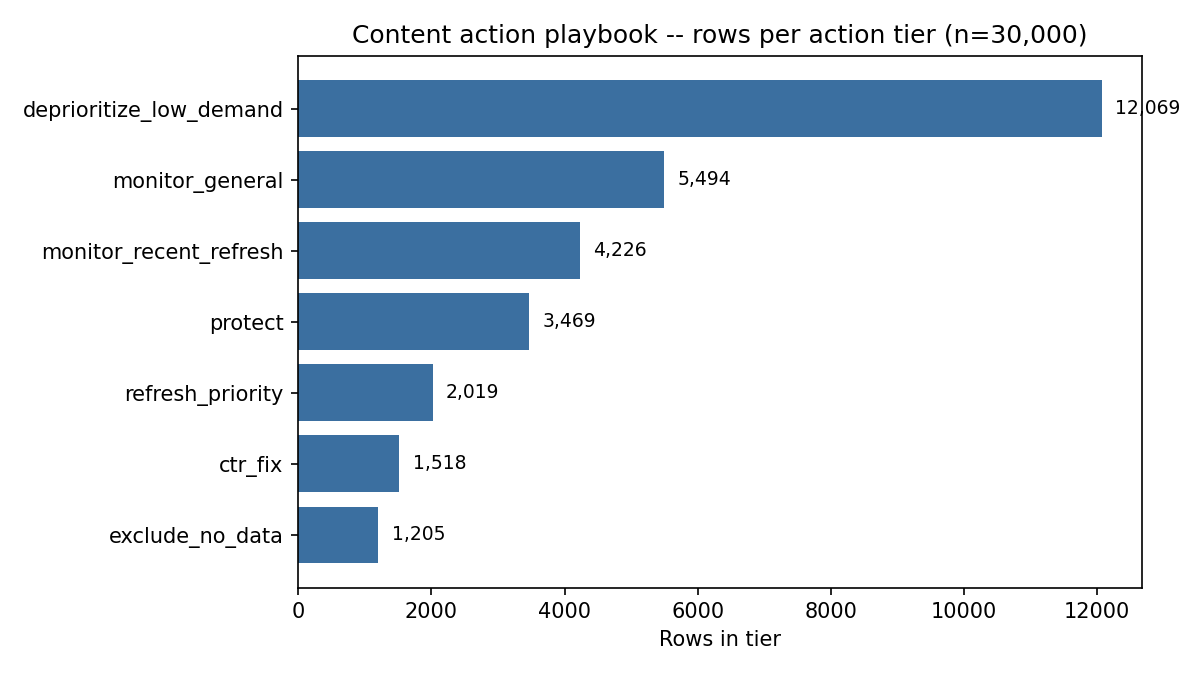


Metrics receipt file: work/outputs/w07_action_playbook_metrics.json
{
  "notebook": "w07_action_playbook",
  "model": "RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20)",
  "validation": "GroupKFold(n_splits=5) by client_id, out-of-fold probabilities pooled across all rows",
  "fold_aucs": [
    0.653,
    0.63,
    0.732,
    0.654,
    0.667
  ],
  "fold_auc_mean": 0.667,
  "single_split_grouped_auc_w06_reference": 0.763,
  "baseline_rule_precision_at_50_w05_reference": 0.8,
  "baseline_rule_precision_at_flagged_count_w05_reference": 1.0,
  "label_base_rate": 0.542,
  "n_clients": 32,
  "action_tier_counts": {
    "deprioritize_low_d ...


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from IPython.display import Image, display
print("Embedding: work/figures/w07_action_tier_counts.png")
display(Image("work/figures/w07_action_tier_counts.png"))
print("\nMetrics receipt file: work/outputs/w07_action_playbook_metrics.json")
print(json.dumps(metrics, indent=2)[:600], "...")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.